## Q. No. 1 Autoencoding and GANs
### a) Explain the basic architecture of an autoencoder. What are the main components and what is their purpose?

Autoencoder has two main components. **1. Encoder**: it takes the data as the input, encode it into a low-dimensional representation which save the important features and ignores the noise in data. **2.Decoder**: it takes the latent representation after encoder as the input and decode the original input data as the output. Autoencoder minimizing the reconstruction error making the the encoder can successfully encode the data into latent representation and can decode the original data from this  representation.


### b) What is the difference between undercomplete and overcomplete autoencoders? Which one is generally preferred and why?

**undercomplete：** Dimensions of the latent representation is fewer  than that of the input data. So the autoencoder learn a small and compressed representation which save the most important features. **overcomplete**: Dimensions of the latent representation is larger  than that of the input data. The aucoder may just copy the input data as the latent representation without learn any feature. **undercomplete is preferred** because the aim of autoencoder is to learn a low-dimensional and compressed representation which has the useful features.


### c) Explain the concept of adversarial loss in GANs. How does it differ from traditional loss functions?

GANs have a Generator and a Discriminator, the adversarial loss is from the competing between them. Generator generate the data making the Discriminator can not distinguish it is fake or not. Discriminator try to distinguish the data is fake or not. Compared with the traditional loss function, adversarial loss focus on two parts (Generator and a Discriminator) the loss is a competing between these two parts but traditional loss function just optimize a single target.

### d) What are the challenges faced when training GANs? Name at least three and explain them briefly.
1. The training process is not stable because the training and competing process between the Generator and a Discriminator is very sensitive to the hyperparameters, a little change may affect the quality of the generated data. 

2. mode collapes: the generator may focus on generate the sample with a limited classes whcih making the sample have bad diversity.  

3. The training is hard to converge. The Generator and a Discriminator is keep competing making the adversarial loss can not converge.


### References of the Code:

https://github.com/chenjie/PyTorch-CIFAR-10-autoencoder

https://github.com/Ksuryateja/DCGAN-CIFAR10-pytorch

## Q. No. 2 Autoencoding

In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
"""
1. Load and preprocess the CIFAR-10 dataset. Normalize the pixel values and split into training and test sets
"""
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # normalize
])

# create training and testing set
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_data  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=256, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # gpu device

In [ ]:
"""
2. Implement a simple dense autoencoder for the CIFAR-10 dataset. The encoder should 
reduce the input to a 256-dimensional latent space

"""
class Dense_model(nn.Module):
    """
    dense autoencoder .
    input :3x32x3
    output : 256 dim
    """
    def __init__(self):
        super(Dense_model, self).__init__()

        self.e = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(True),
            nn.Linear(512, 256) # 256-dimensional latent space
        )
        self.d = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 32 * 32 * 3),
            nn.Tanh(),
            nn.Unflatten(1, (3, 32, 32))
        )

    def forward(self, x):
        latent = self.e(x)
        result = self.d(latent)
        return result

Dense autoencoder: epoch 1/50, Training Loss: 0.0674, Testing Loss: 0.0418
Dense autoencoder: epoch 2/50, Training Loss: 0.0358, Testing Loss: 0.0328
Dense autoencoder: epoch 3/50, Training Loss: 0.0301, Testing Loss: 0.0290
Dense autoencoder: epoch 4/50, Training Loss: 0.0268, Testing Loss: 0.0263
Dense autoencoder: epoch 5/50, Training Loss: 0.0246, Testing Loss: 0.0241
Dense autoencoder: epoch 6/50, Training Loss: 0.0226, Testing Loss: 0.0228
Dense autoencoder: epoch 7/50, Training Loss: 0.0211, Testing Loss: 0.0210
Dense autoencoder: epoch 8/50, Training Loss: 0.0200, Testing Loss: 0.0200
Dense autoencoder: epoch 9/50, Training Loss: 0.0190, Testing Loss: 0.0192
Dense autoencoder: epoch 10/50, Training Loss: 0.0183, Testing Loss: 0.0186
Dense autoencoder: epoch 11/50, Training Loss: 0.0177, Testing Loss: 0.0184
Dense autoencoder: epoch 12/50, Training Loss: 0.0171, Testing Loss: 0.0173
Dense autoencoder: epoch 13/50, Training Loss: 0.0166, Testing Loss: 0.0171
Dense autoencoder: ep

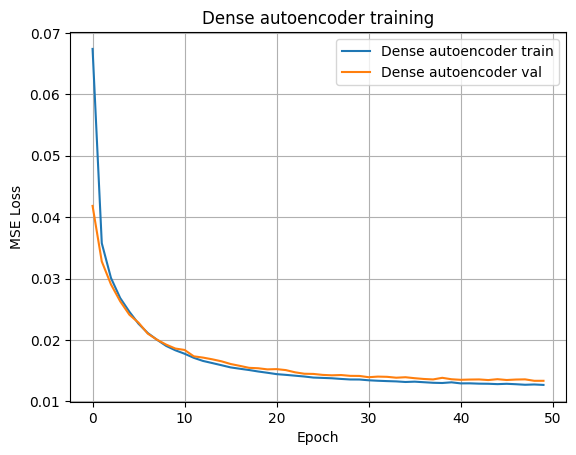

In [ ]:
"""
3. Train the autoencoder for 50 epochs with a batch size of 256. Plot the training and 
validation loss
"""

def train(model, model_name, epochs=50):

    """
    train the model
    return the model with training loss list and testing loss list
    """

    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_list = [] # a list for training loss within a batch
    val_loss_list = [] # validate loss

    for epoch in range(epochs):
        model.train() # training mode
        loss_all = 0 # sum of the loss

        for img, _ in train_loader:
            img = img.to(device)
            res = model(img)
            loss = criterion(res, img)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_all += loss.item()


        train_loss_list.append(loss_all / len(train_loader))


        #  Test set 
        model.eval() # evaluating mode
        val_loss_test = 0 # validate loss
        with torch.no_grad():
            for img, _ in test_loader:
                img = img.to(device)
                res = model(img)
                loss = criterion(res, img)
                val_loss_test += loss.item()


        val_loss_list.append(val_loss_test / len(test_loader))

        print(f"{model_name}: epoch {epoch+1}/{epochs}, Training Loss: {train_loss_list[-1]:.4f}, Testing Loss: {val_loss_list[-1]:.4f}")

    return model, train_loss_list, val_loss_list


dense_model, train_loss_dense, val_loss_dense = train(Dense_model(), "Dense autoencoder") # train the model with 550 epochs


#Plot the training and validation loss
plt.plot(train_loss_dense, label="Dense autoencoder train")
plt.plot(val_loss_dense, label="Dense autoencoder val")
plt.title("Dense autoencoder training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
"""
4. Implement a convolutional autoencoder that uses Conv2D and MaxPooling2D layers in 
the encoder, and Conv2D and UpSampling2D layers in the decoder.
"""

class conv_model(nn.Module):

    """
    convolutional autoencoder
    
    """
    def __init__(self):
        super(conv_model, self).__init__()
        self.e = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  # conv2d
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),              # maxpooling 2d
            nn.Conv2d(32, 64, 3, padding=1), 
            nn.ReLU(True),
            nn.MaxPool2d(2, 2)               
        )

        self.d = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1), # conv2d
            nn.ReLU(True),
            nn.Upsample(scale_factor=2), # UpSampling2D
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(True),
            nn.Upsample(scale_factor=2), 
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        latent=self.e(x)
        result=self.d(latent)
        return result

convolutional autoencoder: epoch 1/50, Training Loss: 0.0526, Testing Loss: 0.0287
convolutional autoencoder: epoch 2/50, Training Loss: 0.0249, Testing Loss: 0.0225
convolutional autoencoder: epoch 3/50, Training Loss: 0.0212, Testing Loss: 0.0198
convolutional autoencoder: epoch 4/50, Training Loss: 0.0191, Testing Loss: 0.0187
convolutional autoencoder: epoch 5/50, Training Loss: 0.0179, Testing Loss: 0.0171
convolutional autoencoder: epoch 6/50, Training Loss: 0.0169, Testing Loss: 0.0161
convolutional autoencoder: epoch 7/50, Training Loss: 0.0161, Testing Loss: 0.0155
convolutional autoencoder: epoch 8/50, Training Loss: 0.0154, Testing Loss: 0.0148
convolutional autoencoder: epoch 9/50, Training Loss: 0.0149, Testing Loss: 0.0149
convolutional autoencoder: epoch 10/50, Training Loss: 0.0146, Testing Loss: 0.0140
convolutional autoencoder: epoch 11/50, Training Loss: 0.0140, Testing Loss: 0.0135
convolutional autoencoder: epoch 12/50, Training Loss: 0.0138, Testing Loss: 0.0134
c

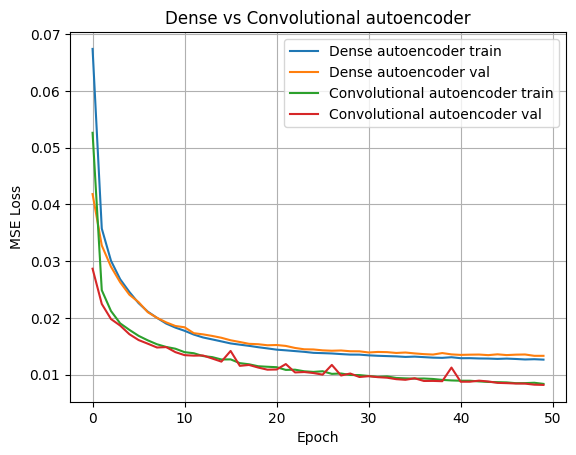

In [ ]:
"""
5. Train the convolutional autoencoder and compare its performance with the dense 
autoencoder. 
"""

conv_model, train_loss_conv, val_loss_conv = train(conv_model(), "convolutional autoencoder") # train the conv model


# compare its performance with the dense autoencoder by training and validation loss
plt.plot(train_loss_dense, label="Dense autoencoder train")
plt.plot(val_loss_dense, label="Dense autoencoder val")
plt.plot(train_loss_conv, label="Convolutional autoencoder train")
plt.plot(val_loss_conv, label="Convolutional autoencoder val")
plt.title("Dense vs Convolutional autoencoder")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

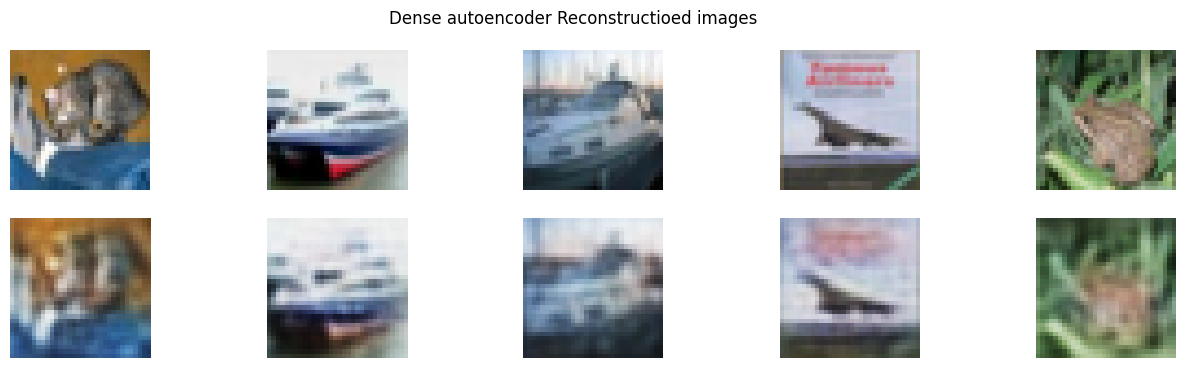

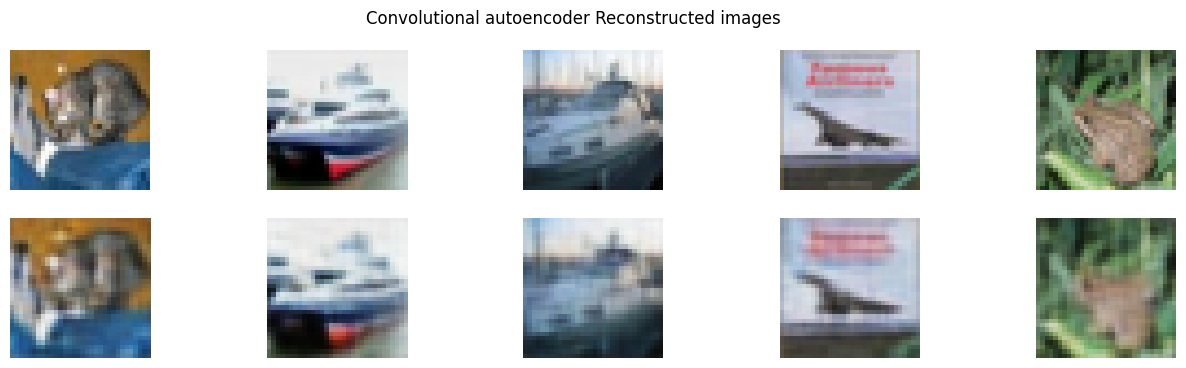

In [ ]:
"""
5. Display some reconstructed images from both models.

"""
def reconstruction(model, model_name ,number=5):
    """
    display reconstructed images
    number: number of the displayed images
    
    """


    model.eval()
    with torch.no_grad():
        imgs, _ = next(iter(test_loader)) # original image
        imgs = imgs[:number].to(device)
        reconstructed = model(imgs).cpu() # reconstructed images
        imgs = imgs.cpu()

    _, ax = plt.subplots(2, number, figsize=(16, 4))

    for i in range(number):
        
        ax[0, i].imshow(imgs[i].permute(1, 2, 0) * 0.5 + 0.5)
        ax[0, i].axis('off')
        ax[1, i].imshow(reconstructed[i].permute(1, 2, 0) * 0.5 + 0.5)
        ax[1, i].axis('off')

    plt.suptitle(model_name)
    plt.show()

reconstruction(dense_model, "Dense autoencoder Reconstructioed images")
reconstruction(conv_model, "Convolutional autoencoder Reconstructed images")

## Q. No. 3 Generative Adversarial Networks (GANs)

In [ ]:
"""
1. Implement the generator network for the DCGAN. It should take a 100-dimensional 
noise vector as input and output a 32x32x3 image
"""
class Gen(nn.Module):
    """
    generator network
    input : in_dim (100)
    output: 32x32x3
    """

    def __init__(self, in_dim=100):
        super().__init__()
        self.gen = nn.Sequential(
            nn.ConvTranspose2d(in_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()  
        )

    def forward(self, x):
        return self.gen(x) # 3x32x32 output
    


"""
2. Implement the discriminator network for the DCGAN. It should take a 32x32x3 image as 
input and output a binary classification (real/fake)
"""

class Dis(nn.Module):
    """
    Discriminator.
    input:32x3x3
    output: 0,1
    """
    def __init__(self):

        super().__init__()
        self.dis = nn.Sequential(
            nn.Conv2d(3, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.dis(x).view(-1)


In [ ]:


"""
4. Define the GAN model that combines the generator and discriminator. Implement the 
training loop that alternates between training the discriminator and generator
"""

"""
5.During training, periodically generate and save sample images from the generator to 
monitor its progress.
"""

import torch.optim as optim
from torchvision.utils import save_image


gen = Gen().to("cuda") # geneator
dis = Dis().to("cuda")# Discriminator

loss_func = nn.BCELoss() # loss function

# optimizer for geneator and Discriminator
optim_gen = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999)) 
optim_disc = optim.Adam(dis.parameters(), lr=2e-4, betas=(0.5, 0.999))

# fixed noise for generation adn visualize
Noise = torch.randn(64, 100, 1, 1).to("cuda")


"""
start training process with 50 epochs
"""
for epoch in range(1, 50 + 1):
    for real_img, _ in train_loader:
        real_img = real_img.to(device)
        batch_size = real_img.size(0)

        # real and fake labels
        r_label = torch.ones(batch_size, device=device)
        f_label = torch.zeros(batch_size, device=device)

        # train the Discriminator
        noise = torch.randn(batch_size, 100, 1, 1, device=device)# random noise
        fake_img = gen(noise)

        # real and fake prediction
        r_pred = dis(real_img)
        f_pred = dis(fake_img.detach())

        loss_d = loss_func(r_pred, r_label) + loss_func(f_pred, f_label) # loss of Discriminator

        optim_disc.zero_grad()
        loss_d.backward()
        optim_disc.step()

        # train the geneator
        f_pred = dis(fake_img) # prediction of the fake image
        lossG = loss_func(f_pred, r_label)  # competing Discriminator

        optim_gen.zero_grad()
        lossG.backward()
        optim_gen.step()

    print(f"epoch {epoch}/{50}, Loss dis: {loss_d.item():.2f}, Loss gen: {lossG.item():.2f}")


    # periodically generate and save sample images, every 10 epochs
    if epoch % 10 == 0 :
        gen.eval()# evaluating mode
        with torch.no_grad():
            gen_img = gen(Noise).detach().cpu()

        gen_img = gen_img * 0.5 + 0.5  # inversion of normalization
        save_image(gen_img, f"Sample/fake_img_{epoch:03d}.png", nrow=4)# save the image
        gen.train()# trainging mode



epoch 1/50, Loss dis: 0.36, Loss gen: 4.43
epoch 2/50, Loss dis: 0.36, Loss gen: 3.27
epoch 3/50, Loss dis: 1.24, Loss gen: 1.25
epoch 4/50, Loss dis: 0.46, Loss gen: 2.67
epoch 5/50, Loss dis: 0.66, Loss gen: 2.28
epoch 6/50, Loss dis: 0.75, Loss gen: 1.89
epoch 7/50, Loss dis: 0.34, Loss gen: 3.41
epoch 8/50, Loss dis: 0.59, Loss gen: 3.42
epoch 9/50, Loss dis: 0.92, Loss gen: 3.02
epoch 10/50, Loss dis: 1.08, Loss gen: 2.09
epoch 11/50, Loss dis: 0.59, Loss gen: 2.97
epoch 12/50, Loss dis: 1.46, Loss gen: 6.25
epoch 13/50, Loss dis: 0.57, Loss gen: 1.74
epoch 14/50, Loss dis: 0.46, Loss gen: 2.29
epoch 15/50, Loss dis: 1.53, Loss gen: 5.37
epoch 16/50, Loss dis: 1.95, Loss gen: 5.99
epoch 17/50, Loss dis: 0.47, Loss gen: 2.63
epoch 18/50, Loss dis: 0.74, Loss gen: 2.65
epoch 19/50, Loss dis: 0.28, Loss gen: 2.96
epoch 20/50, Loss dis: 0.91, Loss gen: 1.22
epoch 21/50, Loss dis: 1.41, Loss gen: 6.30
epoch 22/50, Loss dis: 0.37, Loss gen: 3.07
epoch 23/50, Loss dis: 1.83, Loss gen: 7.

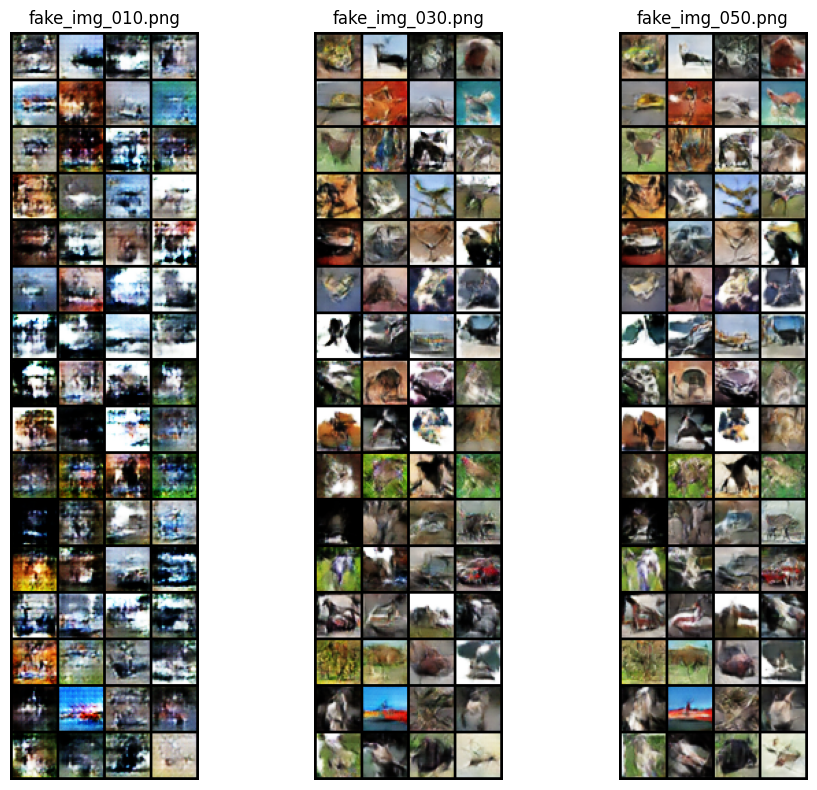

In [ ]:
"""
5.During training, periodically generate and save sample images from the generator to 
monitor its progress.

Save sample images from the generator to 
monitor its progress.
"""

import os
import matplotlib.pyplot as plt
from PIL import Image

# path  of the image
sample_images = [
    "/home/chunjielu/25sum/DL/Sample/fake_img_010.png",
    "/home/chunjielu/25sum/DL/Sample/fake_img_030.png",
    "/home/chunjielu/25sum/DL/Sample/fake_img_050.png"
    
]

# Display the image
fig, axes = plt.subplots(1, len(sample_images), figsize=(10, 8))
for ax, path in zip(axes, sample_images):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(os.path.basename(path))
    ax.axis('off')
    
plt.tight_layout()
plt.show()


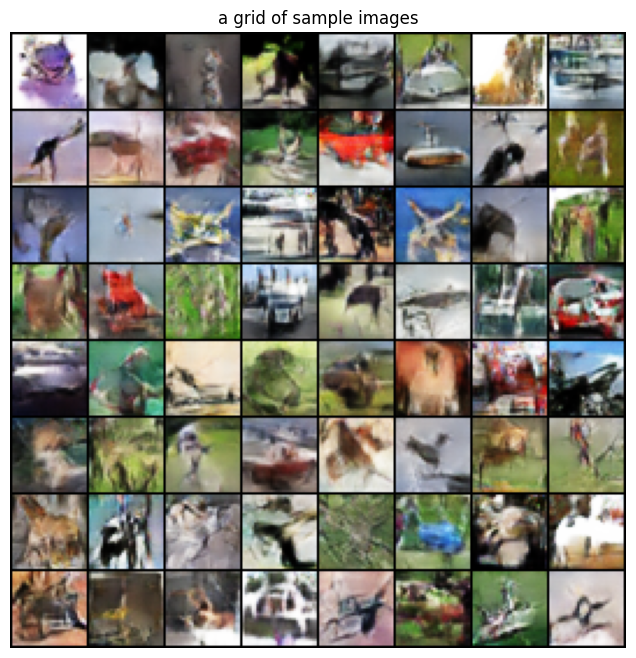

In [37]:
"""
5. After training, evaluate the GAN

"""

"""
a. Generating a grid of sample images.
"""

import torchvision.utils as vutils
import matplotlib.pyplot as plt

# use a fixed noise to generate the image
Noise = torch.randn(64, 100, 1, 1).to("cuda")

gen.eval() # evaluatioin mode of geneator
with torch.no_grad():
    fake_images = gen(Noise).cpu() # generate the fake image

# turn into  [0,1] to visualize
fake_images = fake_images * 0.5 + 0.5

# create the grid
grid = vutils.make_grid(fake_images, nrow=8, padding=1, normalize=False)

# visualize the grid
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("a grid of sample images")
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.show()


In [ ]:
"""
b. Implementing a simple metric to evaluate diversity (like calculating the standard 
deviation of pixel values across samples)
"""

def eval_gen(generator, num=1000):
    """
    evaluate the diversity of generated samples with 1,000 images by  
    calculating the standard deviation of pixel values across samples
    """
    noise = torch.randn(num, 100, 1, 1).to("cuda")
    with torch.no_grad():
        generated = generator(noise).cpu()  # 3x32x32
        
    std_gen = generated.std(dim=0).mean().item()
    print(f"Standard deviation of pixel values among {num} images: {std_gen:.3f}")

eval_gen(gen)


Standard deviation of pixel values among 1000 images: 0.488
